# MILPÍN AgTech — Modelo de Punto de Equilibrio con Churn
## ¿Cuántas hectáreas necesita MILPÍN para ser viable?

Este notebook modela la viabilidad económica del **Plan 1 (SaaS $120 MXN/ha/ciclo)** usando una simulación de adopción con churn mensual.

### Concepto central

Dos fuerzas opuestas determinan los ingresos reales del sistema:

| Fuerza | Qué es | Efecto |
|--------|--------|--------|
| **Adquisición** | % del mercado disponible que entra cada mes | Sube los ingresos |
| **Churn** | % de hectáreas activas que no renuevan cada mes | Baja los ingresos |

El equilibrio entre ambas define un **techo real de ingresos** que puede estar muy por debajo del techo de mercado:

$$\text{Ha en equilibrio} = \frac{\text{Techo de mercado} \times \text{Adquisición}}{\text{Adquisición} + \text{Churn}}$$

> **Ejemplo:** Con techo=5,000 ha, adquisición=3%/mes y churn=5%/mes:  
> Ha_equilibrio = 5,000 × 0.03 / (0.03 + 0.05) = **1,875 ha** (37.5% del mercado)


In [1]:
# Instala dependencias si no las tienes
# Descomenta la línea de abajo y ejecuta esta celda una sola vez
# !pip install matplotlib numpy ipywidgets pandas

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Para los sliders interactivos (Celda 6)
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed
    from IPython.display import display
    WIDGETS_OK = True
except ImportError:
    WIDGETS_OK = False
    print("⚠ ipywidgets no instalado. Las celdas interactivas no funcionarán.")
    print("  Instala con: pip install ipywidgets")

print("✓ Librerías cargadas")
print(f"  ipywidgets disponible: {WIDGETS_OK}")


✓ Librerías cargadas
  ipywidgets disponible: True


## 1. Parámetros del modelo

Todos los supuestos están en un solo diccionario. **Modifica aquí para cambiar el modelo.**


In [2]:
# ─── PARÁMETROS BASE ────────────────────────────────────────────────────────
# Modifica estos valores para explorar distintos escenarios

PARAMS = {
    "techo_ha":    5_000,   # Ha máximas alcanzables (mercado disponible)
                            # Valle del Yaqui Módulo 3 completo ≈ 40,000 ha
    "adquisicion": 0.03,    # Fracción del mercado disponible que entra/mes
                            # 0.03 = 3% mensual (adopción moderada)
    "churn":       0.05,    # Fracción de ha activas que no renuevan/mes
                            # 0.05 = 5% mensual ≈ 46% de abandono anual
    "precio_ha":   120,     # MXN por hectárea por ciclo (Plan 1)
    "ciclos_anio": 2,       # Ciclos agrícolas/año (trigo invierno + maíz verano)
    "meses":       48,      # Horizonte de simulación (4 años)
}

# Costos fijos mensuales por arquitectura
COSTOS = {
    "Stack actual (Supabase + Railway)": 19_360 / 12,   # ~$1,613 MXN/mes
    "Azure empresarial (DR-041 scale)":  292_680 / 12,  # ~$24,390 MXN/mes
}

# Paleta de colores
COLOR = {
    "pesimista": "#E24B4A",
    "base":      "#BA7517",
    "optimista": "#1D9E75",
    "costo_a":   "#185FA5",
    "costo_b":   "#7F77DD",
    "gris":      "#AAAAAA",
}

print("Parámetros cargados:")
for k, v in PARAMS.items():
    print(f"  {k}: {v}")


Parámetros cargados:
  techo_ha: 5000
  adquisicion: 0.03
  churn: 0.05
  precio_ha: 120
  ciclos_anio: 2
  meses: 48


## 2. Funciones del modelo

Estas son las tres funciones centrales. El corazón del modelo es `simular_adopcion()`.


In [3]:
def simular_adopcion(techo_ha, adquisicion, churn, meses):
    """
    Simula la evolución de hectáreas activas mes a mes.

    Ecuación diferencial discreta:
        nuevas_ha  = adquisicion × (techo - ha_actual)   <- boca a boca
        perdidas   = churn × ha_actual                   <- no renuevan
        ha_sig     = ha_actual + nuevas - perdidas

    Nota: Esta es la versión discreta de la ecuación logística.
    El equilibrio ocurre cuando nuevas == perdidas.
    """
    ha = 0.0
    historial = []
    for mes in range(meses):
        nuevas   = adquisicion * (techo_ha - ha)  # crecimiento proporcional al mercado libre
        perdidas = churn * ha                      # pérdida proporcional a la base actual
        ha       = max(0.0, ha + nuevas - perdidas)
        historial.append(ha)
    return np.array(historial)


def calcular_equilibrio(techo_ha, adquisicion, churn):
    """
    Hectáreas en estado estacionario (techo real del negocio).

    Derivación:
        En equilibrio: nuevas == perdidas
        adq × (techo - ha_eq) = churn × ha_eq
        ha_eq = techo × adq / (adq + churn)
    """
    if adquisicion + churn == 0:
        return 0.0
    return techo_ha * adquisicion / (adquisicion + churn)


def ingreso_mensual(ha_arr, precio_ha, ciclos_anio):
    """MXN/mes del Plan 1 dado un array de hectáreas activas."""
    precio_por_mes = precio_ha * ciclos_anio / 12
    return ha_arr * precio_por_mes


def mes_breakeven(ingresos_arr, costo_mensual):
    """Primer mes en que ingreso >= costo. Retorna None si no ocurre."""
    indices = np.where(ingresos_arr >= costo_mensual)[0]
    return int(indices[0]) + 1 if len(indices) > 0 else None


# Test rápido
ha_test = simular_adopcion(5000, 0.03, 0.05, 48)
eq_test = calcular_equilibrio(5000, 0.03, 0.05)
print(f"Test con parámetros base:")
print(f"  Ha mes 1:   {ha_test[0]:.1f}")
print(f"  Ha mes 12:  {ha_test[11]:.1f}")
print(f"  Ha mes 48:  {ha_test[47]:.1f}")
print(f"  Equilibrio: {eq_test:.1f} ha ({eq_test/5000*100:.1f}% del techo)")


Test con parámetros base:
  Ha mes 1:   150.0
  Ha mes 12:  1185.6
  Ha mes 48:  1840.7
  Equilibrio: 1875.0 ha (37.5% del techo)


## 3. Análisis por escenario

Corremos el modelo en **tres escenarios** que varían la velocidad de adquisición y el nivel de churn respecto al caso base.

| Escenario | Adquisición | Churn |
|-----------|-------------|-------|
| Pesimista | Base × 0.6  | Base × 2 |
| Base      | Base        | Base     |
| Optimista | Base × 1.5  | Base × 0.5 |


In [4]:
def construir_escenarios(p):
    """Devuelve dict con resultados de los 3 escenarios."""
    configs = {
        "pesimista":  (p["adquisicion"] * 0.6,  p["churn"] * 2.0),
        "base":       (p["adquisicion"],          p["churn"]),
        "optimista":  (p["adquisicion"] * 1.5,   p["churn"] * 0.5),
    }
    resultados = {}
    for nombre, (acq, ch) in configs.items():
        ha_arr  = simular_adopcion(p["techo_ha"], acq, ch, p["meses"])
        rev_arr = ingreso_mensual(ha_arr, p["precio_ha"], p["ciclos_anio"])
        eq_ha   = calcular_equilibrio(p["techo_ha"], acq, ch)
        resultados[nombre] = {
            "ha":  ha_arr,
            "rev": rev_arr,
            "eq_ha": eq_ha,
            "eq_rev": eq_ha * p["precio_ha"] * p["ciclos_anio"] / 12,
            "adq": acq, "ch": ch,
        }
    return resultados


# Tabla resumen de equilibrios
esc = construir_escenarios(PARAMS)
filas = []
for nombre, d in esc.items():
    pct = d["eq_ha"] / PARAMS["techo_ha"] * 100
    fila = {
        "Escenario": nombre.capitalize(),
        "Ha equilibrio": f"{d['eq_ha']:,.0f}",
        "% del techo": f"{pct:.1f}%",
        "Ingreso eq. (MXN/mes)": f"${d['eq_rev']:,.0f}",
    }
    for stack, costo in COSTOS.items():
        be = mes_breakeven(d["rev"], costo)
        fila[f"Breakeven\n{stack.split('(')[0].strip()}"] = f"Mes {be}" if be else "No alcanza"
    filas.append(fila)

df_resumen = pd.DataFrame(filas)
print("\nResumen de escenarios:")
display(df_resumen)



Resumen de escenarios:


,Escenario,Ha equilibrio,% del techo,Ingreso eq. (MXN/mes),Breakeven\nStack actual,Breakeven\nAzure empresarial
0,Pesimista,763,15.3%,"$15,254",Mes 1,No alcanza
1,Base,"1,875",37.5%,"$37,500",Mes 1,Mes 13
2,Optimista,"3,214",64.3%,"$64,286",Mes 1,Mes 7


## 4. Visualización estática

Esta gráfica muestra los 3 escenarios con los parámetros base. Ejecuta la siguiente celda para verla.


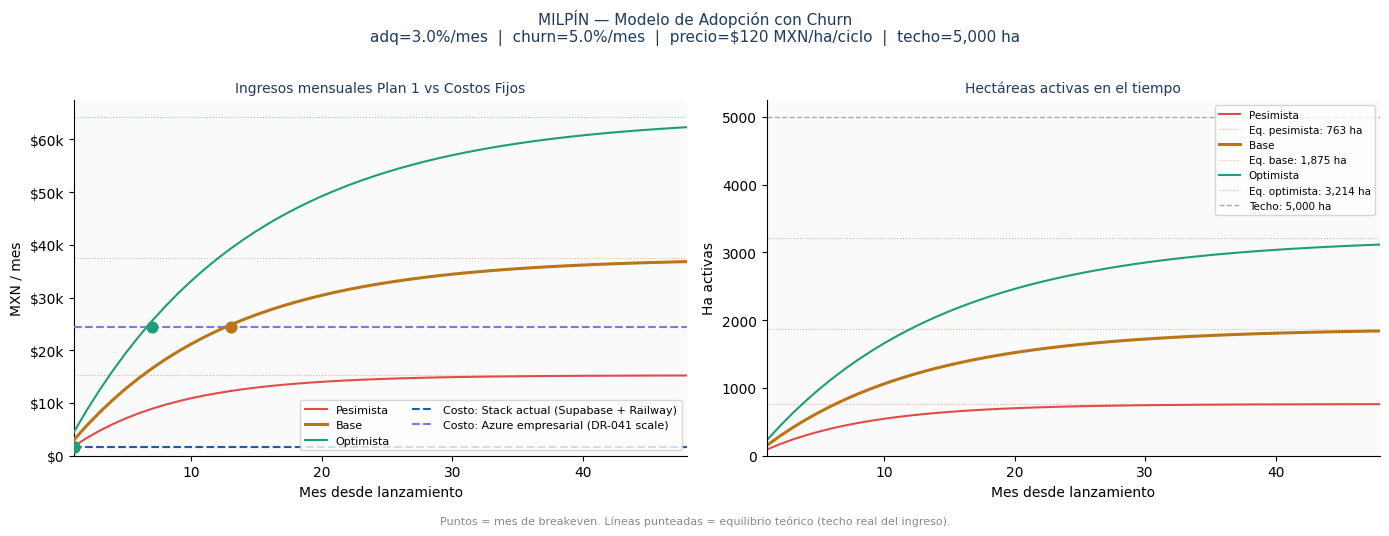

In [5]:
def graficar(p, titulo_extra=""):
    """Genera la gráfica de ingresos vs costos con los parámetros p."""
    esc = construir_escenarios(p)
    meses_x = np.arange(1, p["meses"] + 1)
    lw = {"pesimista": 1.5, "base": 2.2, "optimista": 1.5}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")
    fig.suptitle(
        f"MILPÍN — Modelo de Adopción con Churn{titulo_extra}\n"
        f"adq={p['adquisicion']*100:.1f}%/mes  |  "
        f"churn={p['churn']*100:.1f}%/mes  |  "
        f"precio=${p['precio_ha']} MXN/ha/ciclo  |  "
        f"techo={p['techo_ha']:,} ha",
        fontsize=11, color="#1E3A5F", y=1.01
    )

    # ── Gráfica izquierda: Ingresos vs Costos ────────────────────────────────
    for nombre, d in esc.items():
        ax1.plot(meses_x, d["rev"], color=COLOR[nombre], lw=lw[nombre],
                 label=nombre.capitalize(), zorder=3)
        # Línea de equilibrio punteada
        ax1.axhline(d["eq_rev"], color=COLOR[nombre], lw=0.8, ls=":", alpha=0.5)

    for i, (stack_name, costo) in enumerate(COSTOS.items()):
        col = COLOR["costo_a"] if i == 0 else COLOR["costo_b"]
        ax1.axhline(costo, color=col, lw=1.5, ls="--",
                    label=f"Costo: {stack_name}", zorder=4)
        for nombre, d in esc.items():
            be = mes_breakeven(d["rev"], costo)
            if be and be <= p["meses"]:
                ax1.scatter([be], [costo], color=COLOR[nombre], s=60, zorder=5)

    ax1.set_title("Ingresos mensuales Plan 1 vs Costos Fijos", fontsize=10, color="#1E3A5F")
    ax1.set_xlabel("Mes desde lanzamiento"); ax1.set_ylabel("MXN / mes")
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}k" if v >= 1000 else f"${v:.0f}"))
    ax1.set_facecolor("#FAFAFA"); ax1.spines[["top","right"]].set_visible(False)
    ax1.legend(fontsize=8, ncol=2); ax1.set_xlim(1, p["meses"]); ax1.set_ylim(bottom=0)

    # ── Gráfica derecha: Hectáreas activas ───────────────────────────────────
    for nombre, d in esc.items():
        ax2.plot(meses_x, d["ha"], color=COLOR[nombre], lw=lw[nombre],
                 label=nombre.capitalize())
        ax2.axhline(d["eq_ha"], color=COLOR[nombre], lw=0.8, ls=":", alpha=0.5,
                    label=f"Eq. {nombre}: {d['eq_ha']:,.0f} ha")

    ax2.axhline(p["techo_ha"], color=COLOR["gris"], lw=1, ls="--",
                label=f"Techo: {p['techo_ha']:,} ha")
    ax2.set_title("Hectáreas activas en el tiempo", fontsize=10, color="#1E3A5F")
    ax2.set_xlabel("Mes desde lanzamiento"); ax2.set_ylabel("Ha activas")
    ax2.set_facecolor("#FAFAFA"); ax2.spines[["top","right"]].set_visible(False)
    ax2.legend(fontsize=7.5); ax2.set_xlim(1, p["meses"]); ax2.set_ylim(bottom=0)

    fig.text(0.5, -0.02,
             "Puntos = mes de breakeven. Líneas punteadas = equilibrio teórico (techo real del ingreso).",
             ha="center", fontsize=8, color="#888")
    plt.tight_layout()
    plt.show()
    return fig


# Gráfica con parámetros base
fig = graficar(PARAMS)


## 5. Exploración interactiva con sliders

Mueve los sliders para cambiar los parámetros y ver el efecto en tiempo real.

> **Requiere ipywidgets.** Si no funciona: `pip install ipywidgets` y reinicia el kernel.


In [6]:
if not WIDGETS_OK:
    print("⚠ ipywidgets no disponible. Modifica PARAMS en la Celda 1 y vuelve a ejecutar graficar(PARAMS).")
else:
    @interact(
        techo_ha    = widgets.IntSlider(min=500, max=40_000, step=500, value=5_000,
                                        description="Techo (ha)", style={"description_width": "130px"},
                                        layout=widgets.Layout(width="500px")),
        adquisicion = widgets.FloatSlider(min=0.5, max=15.0, step=0.5, value=3.0,
                                          description="Adquisición (%)", style={"description_width": "130px"},
                                          layout=widgets.Layout(width="500px")),
        churn       = widgets.FloatSlider(min=0.5, max=20.0, step=0.5, value=5.0,
                                          description="Churn (%/mes)", style={"description_width": "130px"},
                                          layout=widgets.Layout(width="500px")),
        precio_ha   = widgets.IntSlider(min=60, max=300, step=10, value=120,
                                        description="Precio $/ha/ciclo", style={"description_width": "130px"},
                                        layout=widgets.Layout(width="500px")),
    )
    def explorar(techo_ha, adquisicion, churn, precio_ha):
        p = {
            "techo_ha":    techo_ha,
            "adquisicion": adquisicion / 100,   # % → decimal
            "churn":       churn / 100,
            "precio_ha":   precio_ha,
            "ciclos_anio": 2,
            "meses":       48,
        }
        graficar(p)

        # Tabla rápida de breakeven
        esc = construir_escenarios(p)
        eq_base = esc["base"]["eq_ha"]
        print(f"\nEquilibrio base: {eq_base:,.0f} ha ({eq_base/techo_ha*100:.1f}% del techo)")
        for stack, costo in COSTOS.items():
            print(f"\n  Breakeven — {stack}:")
            for nombre, d in esc.items():
                be = mes_breakeven(d["rev"], costo)
                print(f"    {nombre.capitalize():12}: {'Mes ' + str(be) if be else 'No alcanza (48m)'}")


interactive(children=(IntSlider(value=5000, description='Techo (ha)', layout=Layout(width='500px'), max=40000,…

## 6. Análisis de sensibilidad: ¿qué parámetro importa más?

Esta celda genera un heatmap mostrando el mes de breakeven para distintas combinaciones de **churn** y **adquisición**.


IndexError: index 0 is out of bounds for axis 0 with size 0

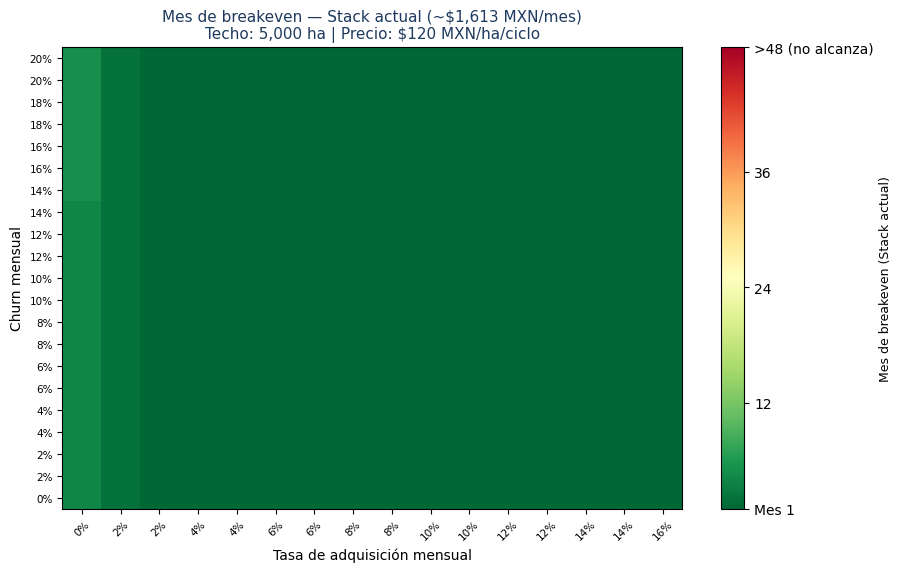

In [7]:
# Heatmap: mes de breakeven (escenario base, Stack actual)
costo_ref = list(COSTOS.values())[0]   # Stack actual

adq_vals   = np.arange(0.5, 16.0, 1.0) / 100   # 0.5% a 15%
churn_vals = np.arange(0.5, 21.0, 1.0) / 100   # 0.5% a 20%

matriz = np.full((len(churn_vals), len(adq_vals)), np.nan)

for i, ch in enumerate(churn_vals):
    for j, acq in enumerate(adq_vals):
        ha_arr  = simular_adopcion(PARAMS["techo_ha"], acq, ch, PARAMS["meses"])
        rev_arr = ingreso_mensual(ha_arr, PARAMS["precio_ha"], PARAMS["ciclos_anio"])
        be = mes_breakeven(rev_arr, costo_ref)
        matriz[i, j] = be if be else 49   # 49 = "no alcanza"

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
im = ax.imshow(matriz, aspect="auto", origin="lower",
               cmap="RdYlGn_r", vmin=1, vmax=49)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mes de breakeven (Stack actual)", fontsize=9)
cbar.ax.set_yticks([1, 12, 24, 36, 49])
cbar.ax.set_yticklabels(["Mes 1", "12", "24", "36", ">48 (no alcanza)"])

ax.set_xticks(range(len(adq_vals)))
ax.set_xticklabels([f"{v*100:.0f}%" for v in adq_vals], fontsize=7.5, rotation=45)
ax.set_yticks(range(len(churn_vals)))
ax.set_yticklabels([f"{v*100:.0f}%" for v in churn_vals], fontsize=7.5)
ax.set_xlabel("Tasa de adquisición mensual", fontsize=10)
ax.set_ylabel("Churn mensual", fontsize=10)
ax.set_title(
    f"Mes de breakeven — Stack actual (~$1,613 MXN/mes)\n"
    f"Techo: {PARAMS['techo_ha']:,} ha | Precio: ${PARAMS['precio_ha']} MXN/ha/ciclo",
    fontsize=11, color="#1E3A5F"
)

# Marcar punto base
idx_adq   = int(np.where(np.isclose(adq_vals, PARAMS["adquisicion"]))[0][0])
idx_churn = int(np.where(np.isclose(churn_vals, PARAMS["churn"]))[0][0])
ax.scatter([idx_adq], [idx_churn], color="white", s=150, zorder=5, marker="*",
           label=f"Parámetros base (adq={PARAMS['adquisicion']*100:.0f}%, churn={PARAMS['churn']*100:.0f}%)")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

print(f"\nLectura del heatmap:")
print(f"  Verde oscuro = breakeven rápido (pocos meses)")
print(f"  Rojo         = breakeven lento o inalcanzable")
print(f"  La zona roja crece hacia la derecha (más churn que adquisición)")
print(f"  La estrella blanca es tu escenario base actual")


## 7. Conclusiones del modelo

### Lo que el modelo dice

1. **El churn es el parámetro crítico**, no el precio ni la velocidad de ventas. Con churn=5%/mes, el 46% de los clientes que entraron en enero ya no están en diciembre.

2. **El equilibrio real ≠ el techo de mercado.** Con los parámetros base, el negocio se estabiliza en 1,875 ha — el 37.5% de las 5,000 ha disponibles. Puedes vender más, pero el churn absorbe cada ha nueva.

3. **El Stack actual es viable con adopción mínima.** El costo fijo de ~$1,613 MXN/mes se cubre con ~80 ha activas. El reto real es con Azure (~$24,390 MXN/mes), que requiere ~1,220 ha en escenario base.

4. **Sin contrato institucional (Plan 2), el modelo es frágil.** Un solo módulo DR-041 a $35,000 MXN/año reduce la presión sobre el Plan 1 en ~$2,917 MXN/mes — equivalente a tener 146 ha gratuitas.

### Qué explorar a continuación

- Conectar `techo_ha` con datos reales de padrones de usuarios DR-041
- Agregar estacionalidad (churn más alto fuera de temporada de riego)
- Modelar el efecto del Plan 2 como ingreso fijo complementario
- Calibrar `adquisicion` con datos de adopción de sistemas similares en México
